# DOC-ANNs — Optical Water Class (OWC) Classification

This notebook demonstrates the **OWC classifier** — the first step of the full
DOC-ANNs pipeline that decides which model to apply to each ocean pixel.

The classifier is a Python translation of the original MATLAB algorithm
(`OWC_4gabi.m`) by Mélin & Vantrepotte (2015), using the same look-up tables (LUTs).

## How it works

Each ocean pixel is classified into one of **17 optical water classes** based on
its remote sensing reflectance spectrum Rrs(λ) at 6 bands (412, 443, 490, 510, 560, 670 nm):

```
Step 1 — Normalise spectrum
    area = ∫ Rrs(λ) dλ  (trapezoidal, over 6 bands)
    Y    = log10(Rrs / area)

Step 2 — Mahalanobis distance to each class centroid
    d_i = sqrt[ (Y - μ_i)ᵀ · Σ_i⁻¹ · (Y - μ_i) ]    for i = 1…17

Step 3 — Assign minimum-distance class
    OWC = argmin(d_i) + 1
```

## DOC-ANNs switch

| OWC classes | Water type | DOC model |
|-------------|-----------|-----------|
| 1 – 9 | Optically complex / coastal | **DOC-ANNa** |
| 10 – 17 | Clear open ocean | **DOC-ANNb** |

## References

- Mélin, F., & Vantrepotte, V. (2015). *Remote Sensing of Environment*, 160, 235–251. https://doi.org/10.1016/j.rse.2015.01.023
- Bonelli, A.G., et al. (2022). *Remote Sensing of Environment*, 281, 113227. https://doi.org/10.1016/j.rse.2022.113227


In [11]:
import sys, os
sys.path.insert(0, "..")   # so Python finds the water_classification module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings("ignore")

from water_classification import load_lut, classify, classify_image, normalise_rrs, owc_to_doc_model

LUT_DIR = "../models/OWC_LUT"

mu, sigma = load_lut(LUT_DIR)
print(f"LUT loaded: {mu.shape[0]} classes x {mu.shape[1]} bands")
print(f"Class mean vectors (mu) shape:         {mu.shape}")
print(f"Covariance matrices (sigma) shape:     {sigma.shape}")

LUT loaded: 17 classes x 6 bands
Class mean vectors (mu) shape:         (17, 6)
Covariance matrices (sigma) shape:     (17, 6, 6)


## 1. Visualise the class centroids (LUT)

Each of the 17 optical water classes has a characteristic log-normalised Rrs(λ) spectrum.
Classes 1–9 are optically complex (turbid/coastal); classes 10–17 are progressively clearer.

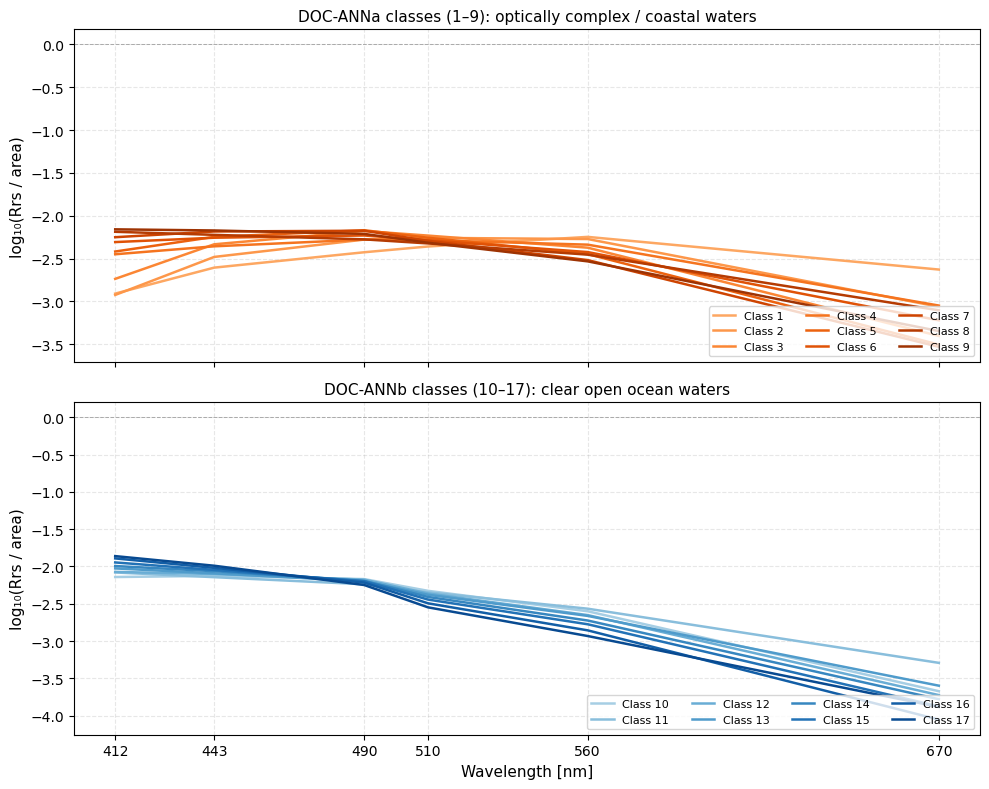

Saved: figures/OWC_class_centroids.png


In [2]:
WAVELENGTHS = np.array([412, 443, 490, 510, 560, 670])

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Colour code: orange for ANNa (1-9), blue for ANNb (10-17)
colors_a = plt.cm.Oranges(np.linspace(0.4, 0.9, 9))
colors_b = plt.cm.Blues(np.linspace(0.35, 0.9, 8))

ax = axes[0]
for i in range(9):
    ax.plot(WAVELENGTHS, mu[i], color=colors_a[i], lw=1.8,
            label=f"Class {i+1}")
ax.set_ylabel("log₁₀(Rrs / area)", fontsize=11)
ax.set_title("DOC-ANNa classes (1–9): optically complex / coastal waters", fontsize=11)
ax.legend(fontsize=8, ncol=3, loc="lower right")
ax.axhline(0, color="#aaa", lw=0.7, ls="--")
ax.grid(True, alpha=0.3, ls="--")

ax2 = axes[1]
for i in range(9, 17):
    ax2.plot(WAVELENGTHS, mu[i], color=colors_b[i-9], lw=1.8,
             label=f"Class {i+1}")
ax2.set_ylabel("log₁₀(Rrs / area)", fontsize=11)
ax2.set_xlabel("Wavelength [nm]", fontsize=11)
ax2.set_title("DOC-ANNb classes (10–17): clear open ocean waters", fontsize=11)
ax2.legend(fontsize=8, ncol=4, loc="lower right")
ax2.axhline(0, color="#aaa", lw=0.7, ls="--")
ax2.grid(True, alpha=0.3, ls="--")
ax2.set_xticks(WAVELENGTHS)

plt.tight_layout()
plt.savefig("../figures/OWC_class_centroids.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: figures/OWC_class_centroids.png")

## 2. Classify the matchup database

We apply the OWC classifier to the in-situ matchup dataset (4346 stations) using
the Rrs(λ) columns extracted from GlobColour at the time and location of each measurement.

In [3]:
matchup = pd.read_csv("../data/matchup.csv")

# Use the GlobColour Rrs at the matchup pixel (suffix _2 = 3x3 median, same 8-day period)
rrs_cols = ["Rrs_412_2","Rrs_443_2","Rrs_490_2","Rrs_510_2","Rrs_560_2","Rrs_670_2"]
rrs = matchup[rrs_cols].values

print(f"Total matchup points: {len(matchup)}")
print(f"Points with valid Rrs: {(~np.any(np.isnan(rrs), axis=1)).sum()}")

classes = classify(rrs, mu, sigma)
models  = owc_to_doc_model(classes)

matchup["OWC"]   = classes
matchup["model"] = models

valid = matchup.dropna(subset=["OWC"])
print(f"Classified: {len(valid)} points")

Total matchup points: 4346
Points with valid Rrs: 1086
Classified: 1068 points


## 3. Class distribution in the matchup dataset

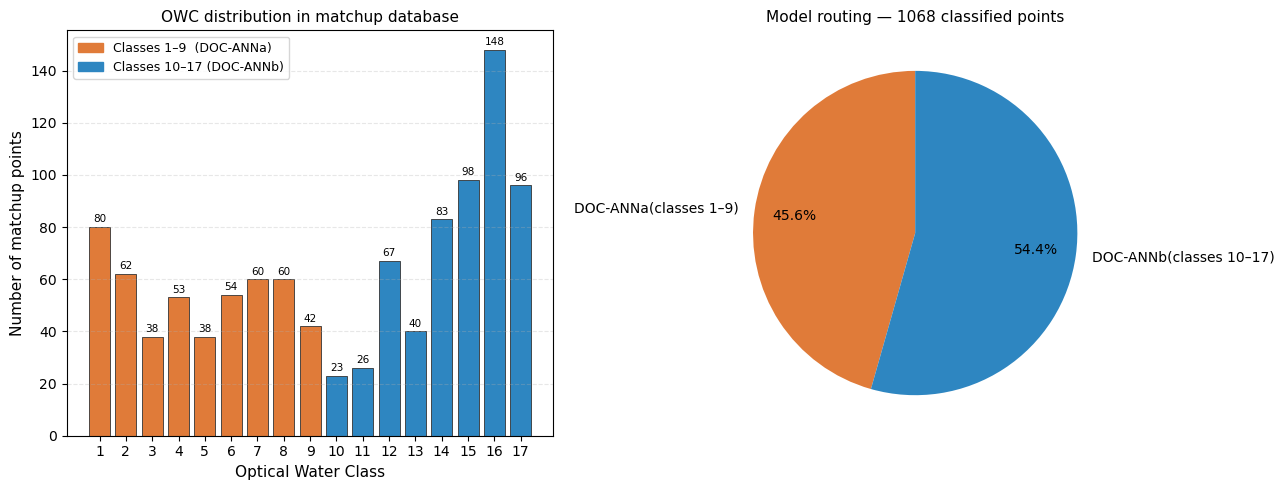

ANNa pixels: 487  |  ANNb pixels: 581


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart of class counts
ax = axes[0]
counts = [int((classes == c).sum()) for c in range(1, 18)]
colors = ["#e07b39"]*9 + ["#2e86c1"]*8
bars = ax.bar(range(1, 18), counts, color=colors, edgecolor="#333", linewidth=0.6)
ax.set_xlabel("Optical Water Class", fontsize=11)
ax.set_ylabel("Number of matchup points", fontsize=11)
ax.set_xticks(range(1, 18))
ax.set_title("OWC distribution in matchup database", fontsize=11)
ax.grid(True, axis="y", alpha=0.3, ls="--")

patch_a = mpatches.Patch(color="#e07b39", label="Classes 1–9  (DOC-ANNa)")
patch_b = mpatches.Patch(color="#2e86c1", label="Classes 10–17 (DOC-ANNb)")
ax.legend(handles=[patch_a, patch_b], fontsize=9)

for bar, cnt in zip(bars, counts):
    if cnt > 0:
        ax.text(bar.get_x() + bar.get_width()/2, cnt + 1, str(cnt),
                ha="center", va="bottom", fontsize=7.5)

# Pie chart ANNa vs ANNb
ax2 = axes[1]
n_a = int(np.nansum((classes >= 1) & (classes <= 9))) if not np.all(np.isnan(classes)) else 0
n_b = int(np.nansum((classes >= 10) & (classes <= 17))) if not np.all(np.isnan(classes)) else 0
n_a = int(np.nansum((classes >= 1)  & (classes <= 9)))
n_b = int(np.nansum((classes >= 10) & (classes <= 17)))
wedges, texts, autotexts = ax2.pie(
    [n_a, n_b], labels=["DOC-ANNa(classes 1–9)", "DOC-ANNb(classes 10–17)"],
    colors=["#e07b39","#2e86c1"], autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 10}, pctdistance=0.75)
ax2.set_title(f"Model routing — {n_a+n_b} classified points", fontsize=11)

plt.tight_layout()
plt.savefig("../figures/OWC_matchup_distribution.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"ANNa pixels: {n_a}  |  ANNb pixels: {n_b}")

## 4. Spatial distribution of OWC classes

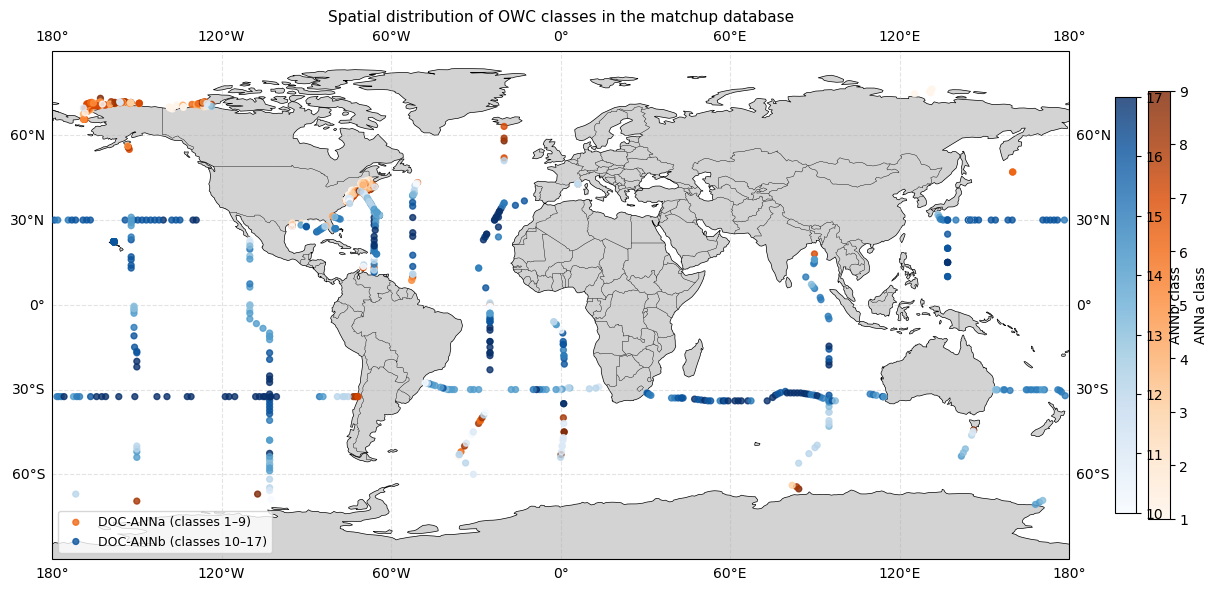

In [15]:
valid = matchup.dropna(subset=["OWC","Lat","Lon"])

# Create map projection
fig = plt.figure(figsize=(13,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add continents and coastlines
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=1)

# ANNa points (classes 1-9)
mask_a = valid["OWC"] <= 9
sc_a = ax.scatter(valid.loc[mask_a, "Lon"], valid.loc[mask_a, "Lat"],
                  c=valid.loc[mask_a, "OWC"], cmap="Oranges",
                  vmin=1, vmax=9, s=18, alpha=0.8, label="DOC-ANNa (classes 1–9)", zorder=3)


# ANNb points (classes 10-17)
mask_b = valid["OWC"] >= 10
sc_b = ax.scatter(valid.loc[mask_b, "Lon"], valid.loc[mask_b, "Lat"],
                  c=valid.loc[mask_b, "OWC"], cmap="Blues",
                  vmin=10, vmax=17, s=18, alpha=0.8, label="DOC-ANNb (classes 10–17)", zorder=4)

# Colorbars
cb_a = plt.colorbar(sc_a, ax=ax, fraction=0.018, pad=0.01, label="ANNa class")
cb_b = plt.colorbar(sc_b, ax=ax, fraction=0.018, pad=0.04, label="ANNb class")

cb_a.set_ticks(range(1, 10))
cb_b.set_ticks(range(10, 18))

# Grid and labels
ax.set_global()
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.35)

ax.legend(fontsize=9, loc="lower left")
ax.set_title("Spatial distribution of OWC classes in the matchup database", fontsize=11)

plt.tight_layout()
plt.savefig("../figures/OWC_spatial_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. In-situ DOC by OWC class

Does the OWC class structure reflect meaningful differences in DOC concentration?

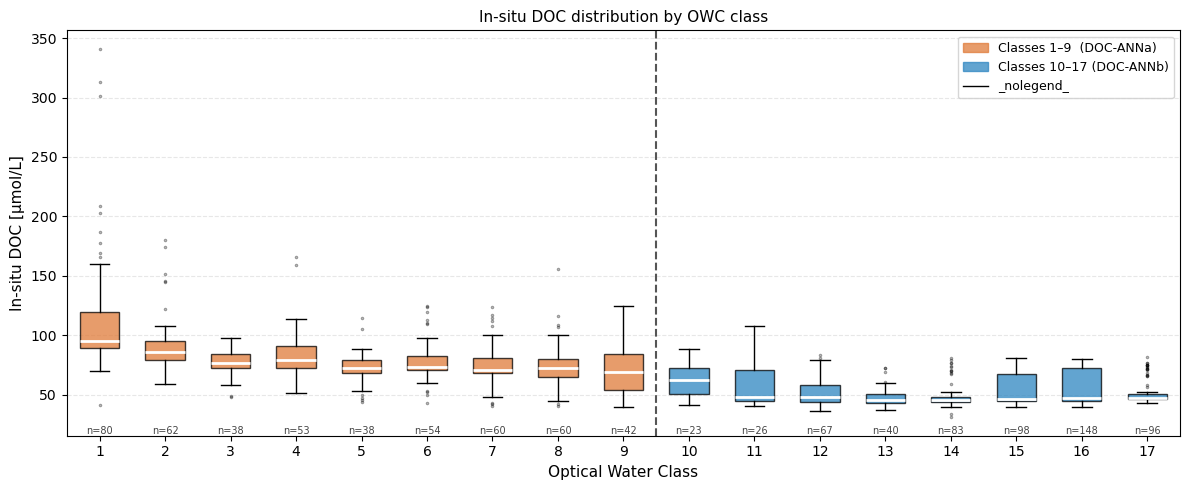

In [16]:
valid = matchup.dropna(subset=["OWC","DOC"])
valid = valid[valid["DOC"] > 0]

fig, ax = plt.subplots(figsize=(12, 5))

positions = list(range(1, 18))
data_by_class = [valid.loc[valid["OWC"] == c, "DOC"].values for c in range(1, 18)]
colors = ["#e07b39"]*9 + ["#2e86c1"]*8

bp = ax.boxplot(data_by_class, positions=positions, patch_artist=True,
                widths=0.6, showfliers=True,
                flierprops=dict(marker=".", ms=3, alpha=0.4),
                medianprops=dict(color="white", lw=2))

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Annotate with N
for i, c in enumerate(range(1, 18)):
    n = len(data_by_class[i])
    ax.text(i+1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 30,
            f"n={n}", ha="center", va="bottom", fontsize=7, color="#444")

ax.set_xlabel("Optical Water Class", fontsize=11)
ax.set_ylabel("In-situ DOC [µmol/L]", fontsize=11)
ax.set_title("In-situ DOC distribution by OWC class", fontsize=11)
ax.set_xticks(range(1, 18))
ax.axvline(9.5, color="#555", ls="--", lw=1.5, label="ANNa | ANNb boundary")
ax.grid(True, axis="y", alpha=0.3, ls="--")
patch_a = mpatches.Patch(color="#e07b39", alpha=0.75, label="Classes 1–9  (DOC-ANNa)")
patch_b = mpatches.Patch(color="#2e86c1", alpha=0.75, label="Classes 10–17 (DOC-ANNb)")
ax.legend(handles=[patch_a, patch_b, ax.get_lines()[0]], fontsize=9)

plt.tight_layout()
plt.savefig("../figures/OWC_DOC_by_class.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Using the classifier in your own code

```python
from water_classification import classify, classify_image, load_lut

# For tabular data (N pixels x 6 bands)
mu, sigma = load_lut("models/OWC_LUT")
owc = classify(rrs_array, mu, sigma)          # shape (N,), values 1-17

# For 2D satellite images (6 arrays of shape nlat x nlon)
owc_map = classify_image(
    [rrs412, rrs443, rrs490, rrs510, rrs560, rrs670],
    lut_dir="models/OWC_LUT"
)                                              # shape (nlat, nlon)

# Route pixels to DOC model
from water_classification import owc_to_doc_model
model_labels = owc_to_doc_model(owc)          # "ANNa" / "ANNb" / ""
```

The full pipeline integrating OWC + DOC estimation is in `examples/predict_from_netcdf.py`.
